In [13]:
library(data.table)
library(dplyr)
library(ggplot2)

In [47]:
meta <- fread("/mnt/users/rachelsavage/paper_minimorf/data/frequent_files/meta.dedoublet.csv")
meta <- meta %>%
mutate(readsinpeaks = FRIP*ATAC_unique_mapped_reads)

In [ ]:
##ok so im gonna have 3 main states that i compare to eachother.
#1. is the broad condition (maybe split by donor) 
#2. louvain states
#3. tfxcondition

In [142]:
down.sample.fx <- function(meta, condition_column, min.reads = 1000000){

    
    meta.in <- meta %>% dplyr::rename(condition.input = !!sym(condition_column))
    
    comp1 <- meta.in %>% dplyr::select(barcode, condition.input, readsinpeaks) %>%
    mutate(total.reads = sum(readsinpeaks))%>%
    group_by(condition.input, total.reads)%>%
    summarize(sum = sum(readsinpeaks)) %>%
    filter(sum > min.reads)%>%
    mutate(fraction.reads = sum/total.reads)
    
    passing.clusters <- unique(comp1$condition.input)
    
    min.reads <- min(comp1$sum)
    
    comp1$downsample.rate <- min.reads/comp1$sum
    
    downsampled <- meta.in %>% 
    filter(condition.input %in% passing.clusters)%>%
    left_join(comp1[,c("condition.input","downsample.rate")])
    set.seed(123)
    
    downsampled <- downsampled %>%
      group_by(condition.input) %>%
      group_modify(~ slice_sample(.x, prop = first(.x$downsample.rate))) %>%
      ungroup()
    downsampled$downsample_type <- condition_column
    return(downsampled)
}

In [143]:
condition <- down.sample.fx(meta = meta, condition_column = "condition")

`summarise()` has grouped output by 'condition.input'. You can override using
the `.groups` argument.
Joining with `by = join_by(condition.input)`


In [ ]:
##louvain

In [129]:
umap <- fread("/mnt/users/rachelsavage/paper_minimorf/data/umaps/umapcoor_leiden.100topics.50nn.0.15dist.txt")
umap <- umap %>%
mutate(louvain = paste0("broad_louvain_", louvain))

In [144]:
meta.in <- meta %>% left_join(umap)
louvain <- down.sample.fx(meta = meta.in, condition_column = "louvain")

Joining with `by = join_by(barcode)`
`summarise()` has grouped output by 'condition.input'. You can override using
the `.groups` argument.
Joining with `by = join_by(condition.input)`


In [ ]:
## tf condition

In [145]:
meta.in <- meta %>% filter(n.tfs == 1) %>% 
mutate(tf.cond = paste0(final.tf, "_", condition))
tfcond <- down.sample.fx(meta = meta.in, condition_column = "tf.cond", min.reads = 740000)

`summarise()` has grouped output by 'condition.input'. You can override using
the `.groups` argument.
Joining with `by = join_by(condition.input)`


`summarise()` has grouped output by 'condition.input'. You can override using
the `.groups` argument.


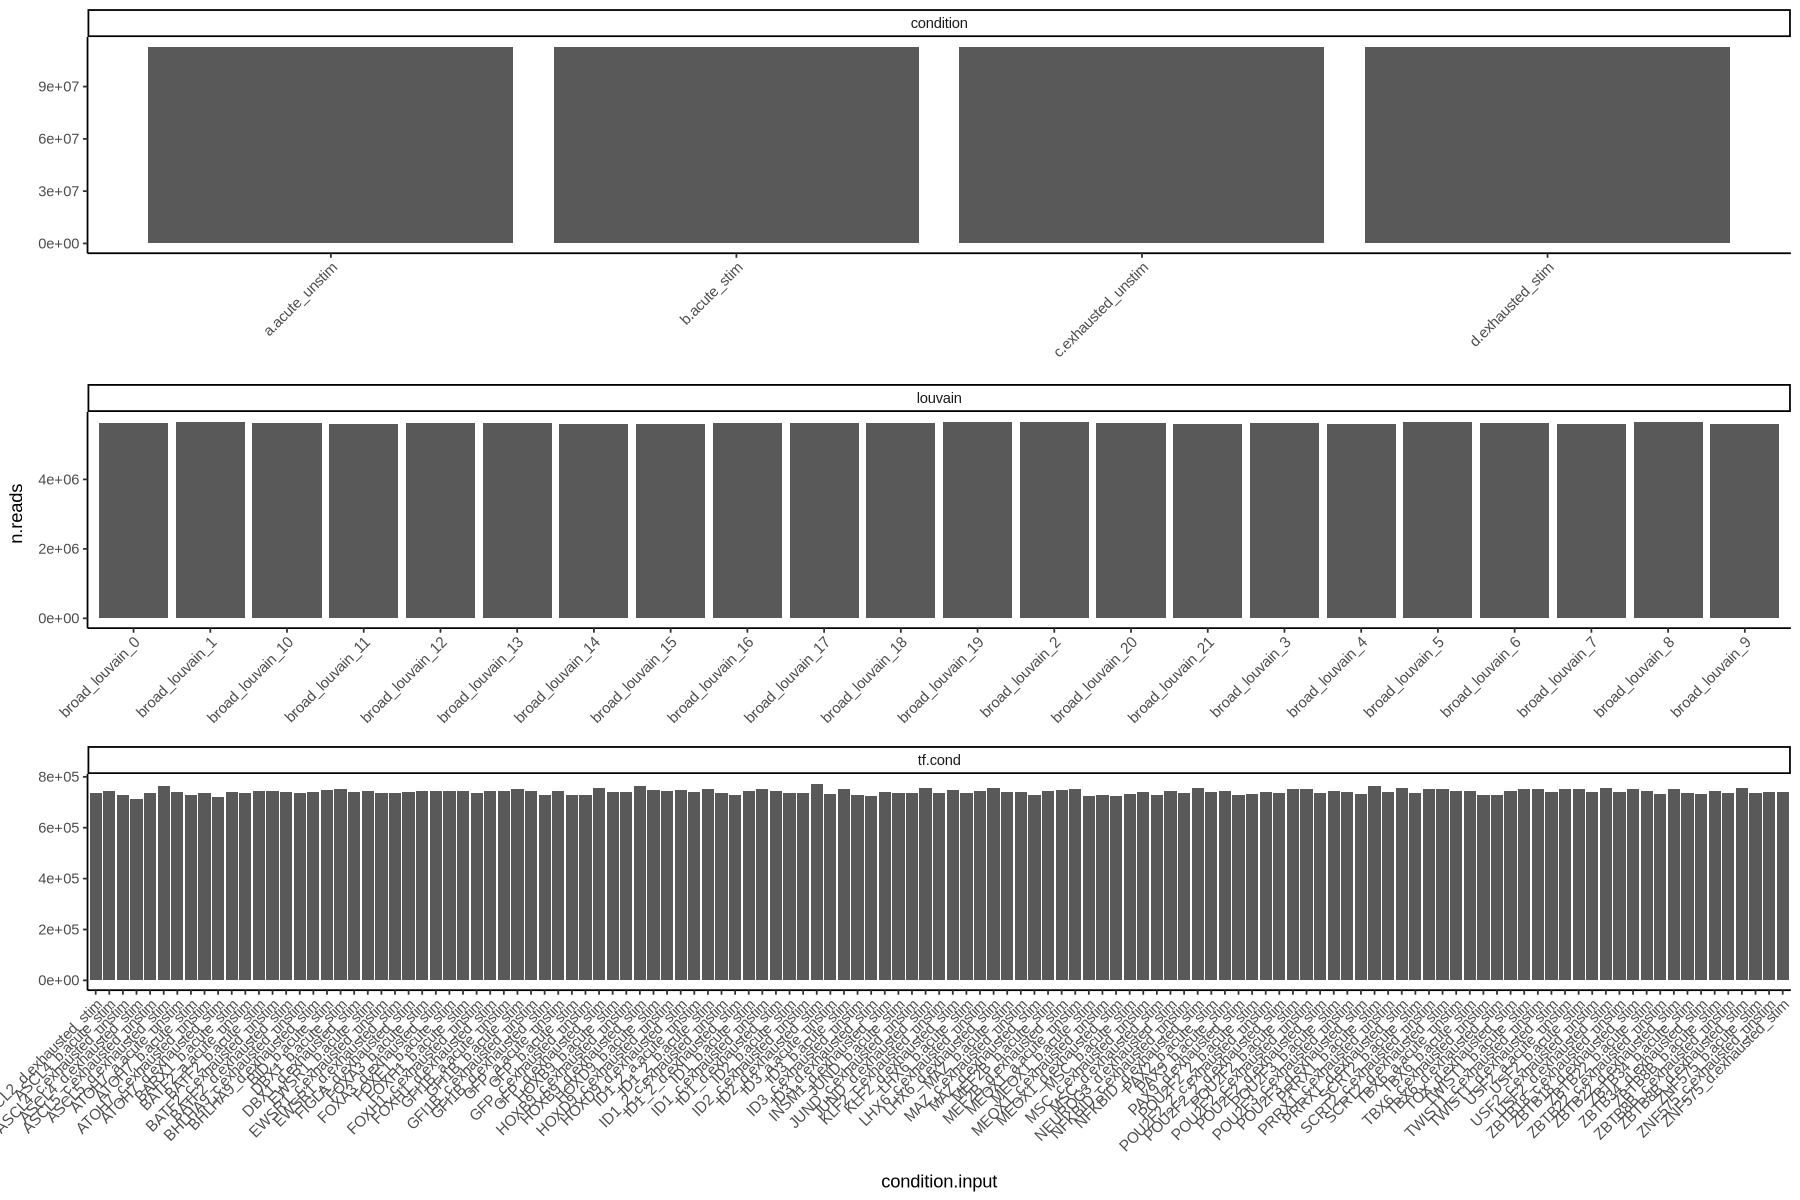

In [160]:
input.cols <- c("condition.input", "barcode", "readsinpeaks", "downsample_type")
all.pseudobulks <- rbind(condition[,input.cols], louvain[,input.cols], tfcond[,input.cols])
summary <- all.pseudobulks %>% group_by(condition.input, downsample_type)%>%
summarize(n.reads = sum(readsinpeaks)) 

options(repr.plot.width = 15, repr.plot.height = 10)

summary %>%
arrange(n.reads)%>%
mutate(condition.input = factor(condition.input, levels = unique(condition.input)))%>%
ggplot(aes(x=condition.input, y= n.reads))+
geom_bar(stat = "identity")+
theme_classic()+
facet_wrap(~downsample_type, scales = "free", ncol = 1)+
theme(axis.text.x = element_text(angle = 45, vjust = 1, hjust=1))


In [152]:
summary %>% group_by(downsample_type)%>%
summarize(mean.rip = mean(n.reads))

downsample_type,mean.rip
<chr>,<dbl>
condition,112652160.0
louvain,5623557.0
tf.cond,741893.6


In [161]:
fwrite(all.pseudobulks[,c("barcode", "condition.input")], 
       "/mnt/users/rachelsavage/paper_minimorf/data/seq2print/pseudobulkids.txt",
      sep = "\t")

In [166]:
input.cols <- c("condition.input", "barcode", "readsinpeaks", "downsample_type")
louvain.write <- (louvain[,input.cols])

fwrite(louvain.write[,c("barcode", "condition.input")], 
       "/mnt/users/rachelsavage/paper_minimorf/data/seq2print/pseudobulkids.louvains.txt",
      sep = "\t")

In [167]:
# ## get embeddings too
# fyi this is the embedding im using for seq2print too
# #topic.mx <- fread("/fab/AlignedData/rsav_minimorf/paper_data/atac_cistopic/out_matrices/celltopic100.txt")